Using device: cuda:0
Loaded shape: (30000, 24)
Using categorical: ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'default']
Using numeric: ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
Starting training (joint modeling including label)...
Epoch 1/500 loss: 0.700438 time: 1.1s
Epoch 2/500 loss: 0.357667 time: 0.3s
Epoch 3/500 loss: 0.324974 time: 0.3s
Epoch 4/500 loss: 0.307361 time: 0.3s
Epoch 5/500 loss: 0.295750 time: 0.3s
Epoch 6/500 loss: 0.284100 time: 0.3s
Epoch 7/500 loss: 0.283348 time: 0.3s
Epoch 8/500 loss: 0.274849 time: 0.3s
Epoch 9/500 loss: 0.273486 time: 0.3s
Epoch 10/500 loss: 0.269370 time: 0.4s
Epoch 11/500 loss: 0.265498 time: 0.3s
Epoch 12/500 loss: 0.265886 time: 0.3s
Epoch 13/500 loss: 0.264740 time: 0.3s
Epoch 14/500 loss: 0.262606 time: 0.3s
Epoch 15/500 loss: 0.263873 time: 0.3s
Epoch 16/500 loss: 0

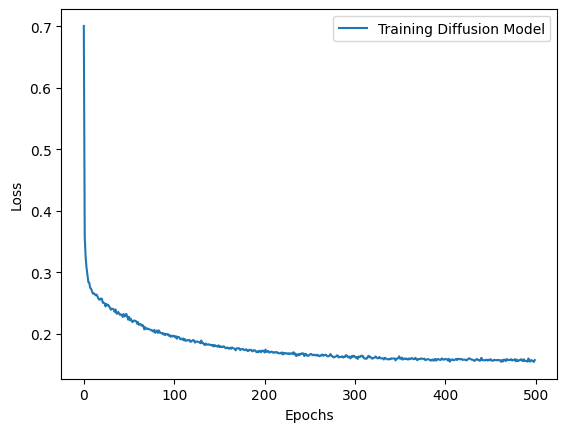

Generated synthetic dataframe preview (first 5 rows):
  SEX EDUCATION MARRIAGE PAY_0 PAY_2 PAY_3 PAY_4 PAY_5 PAY_6  default  ...  \
0   2         2        2     0     0     0     0     0     0        1  ...   
1   2         1        2    -1    -1    -1    -1    -1    -1        0  ...   
2   2         3        1     0     0     0     0     0     0        0  ...   
3   2         2        2     0     0     0     0     0     0        0  ...   
4   1         2        2     6    -1    -1    -1    -1    -1        0  ...   

       BILL_AMT3      BILL_AMT4      BILL_AMT5      BILL_AMT6      PAY_AMT1  \
0   29294.748047   27464.312500   34208.421875   29983.810547   2072.731445   
1     430.125549     390.000000     416.000000     396.000000      0.000000   
2  117636.007812  186212.531250  169673.718750  150333.625000  13336.990234   
3   87500.445312   47892.589844   32618.285156   32348.261719   3009.579834   
4    3803.052979     743.947388    5200.628418   12472.821289   2199.563965   

  

In [1]:
import math
import time
import numpy as np
import pandas as pd
from pathlib import Path
from typing import List, Dict, Tuple
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import QuantileTransformer, LabelEncoder
from sklearn.model_selection import train_test_split

# ---------------------------
# Utilities & Config
# ---------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Hyperparams (tune as required)
EMB_DIM = 2                 # categorical embedding dim (paper used 2)
DIFFUSION_STEPS = 500       # number of diffusion steps
BATCH_SIZE = 512
EPOCHS = 500                # reduce for quick tests; paper used up to 3000
LR = 1e-4
HIDDEN_DIMS = [1024, 1024]  # MLP backbone sizes
BETA_START = 1e-4
BETA_END = 0.02

# ---------------------------
# Data loading & preprocessing
# ---------------------------
def load_credit_default():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"
    df = pd.read_excel(url, header=1)
    df.rename(columns={df.columns[-1]: "default"}, inplace=True)
    if "ID" in df.columns or "id" in df.columns:
        df = df.drop(columns=[c for c in df.columns if c.lower()=="id"])
    return df

df = load_credit_default()
print("Loaded shape:", df.shape)

# --- define columns ---
label_col = "default"   # the label we want to generate jointly
# initial feature lists (based on prior script)
categorical_cols = ["SEX", "EDUCATION", "MARRIAGE", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
# add label column to categorical_cols to model it jointly
if label_col not in categorical_cols:
    categorical_cols = categorical_cols + [label_col]

# numeric columns: everything else except the categorical ones above
numeric_cols = [c for c in df.columns if c not in categorical_cols]

# If numeric_cols contains the label (shouldn't after we added it), remove
numeric_cols = [c for c in numeric_cols if c != label_col]

# Subset df to these columns (ensure order)
df = df[categorical_cols + numeric_cols].copy()
print("Using categorical:", categorical_cols)
print("Using numeric:", numeric_cols)

# Train/test split
train_df, test_df = train_test_split(df, test_size=0.3, random_state=SEED, shuffle=True)

# Numeric preprocessing: quantile transformer
quantile = QuantileTransformer(output_distribution="normal")
train_num = quantile.fit_transform(train_df[numeric_cols].values.astype(float)) if len(numeric_cols) > 0 else np.zeros((len(train_df),0))
test_num = quantile.transform(test_df[numeric_cols].values.astype(float)) if len(numeric_cols) > 0 else np.zeros((len(test_df),0))

# Categorical preprocessing: LabelEncoder per attribute (including label_col)
label_encoders: Dict[str, LabelEncoder] = {}
train_cat_encoded = np.zeros((len(train_df), len(categorical_cols)), dtype=int)
test_cat_encoded = np.zeros((len(test_df), len(categorical_cols)), dtype=int)
vocab_sizes = {}

for i, col in enumerate(categorical_cols):
    le = LabelEncoder()
    train_vals = train_df[col].astype(str).values
    test_vals = test_df[col].astype(str).values
    le.fit(np.concatenate([train_vals, test_vals]))
    label_encoders[col] = le
    train_cat_encoded[:, i] = le.transform(train_vals)
    test_cat_encoded[:, i] = le.transform(test_vals)
    vocab_sizes[col] = len(le.classes_)

# Convert to tensors (note: no separate y label used — label is modeled as categorical input)
x_train_num = torch.tensor(train_num, dtype=torch.float32).to(device)
x_train_cat = torch.tensor(train_cat_encoded, dtype=torch.long).to(device)

x_test_num = torch.tensor(test_num, dtype=torch.float32).to(device)
x_test_cat = torch.tensor(test_cat_encoded, dtype=torch.long).to(device)

train_dataset = TensorDataset(x_train_cat, x_train_num)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

# ---------------------------
# Model building blocks
# ---------------------------
def get_beta_schedule(beta_start: float, beta_end: float, T: int) -> torch.Tensor:
    return torch.linspace(beta_start, beta_end, T, dtype=torch.float32)

class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half = self.dim // 2
        emb = math.log(10000) / (half - 1)
        emb = torch.exp(torch.arange(half, device=device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
        if self.dim % 2 == 1:
            emb = F.pad(emb, (0,1))
        return emb

class MLPBackbone(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: List[int], out_dim: int):
        super().__init__()
        layers = []
        last = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(last, h))
            layers.append(nn.GELU())
            last = h
        layers.append(nn.Linear(last, out_dim))
        self.net = nn.Sequential(*layers)
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
    def forward(self, x):
        return self.net(x)

# ---------------------------
# Main synthesizer model
# ---------------------------
class FinDiffSynthesizer(nn.Module):
    def __init__(self,
                 categorical_cols: List[str],
                 vocab_sizes: Dict[str,int],
                 num_continuous: int,
                 cat_emb_dim: int = 2,
                 hidden_dims: List[int] = [1024, 1024]):
        super().__init__()
        self.categorical_cols = categorical_cols
        self.cat_emb_dim = cat_emb_dim

        # Per-attribute embeddings (trainable)
        self.embeddings = nn.ModuleDict({
            col: nn.Embedding(num_tokens, cat_emb_dim)
            for col, num_tokens in vocab_sizes.items()
        })

        self.total_cat_dim = len(categorical_cols) * cat_emb_dim
        self.num_continuous = num_continuous
        self.input_dim = self.total_cat_dim + self.num_continuous

        model_dim = max(512, self.input_dim)
        self.input_proj = nn.Linear(self.input_dim, model_dim)

        self.time_emb = SinusoidalPosEmb(64)
        self.time_mlp = nn.Sequential(
            nn.Linear(64, model_dim),
            nn.GELU(),
            nn.Linear(model_dim, model_dim)
        )

        self.backbone = MLPBackbone(input_dim=model_dim, hidden_dims=hidden_dims, out_dim=model_dim)
        self.head = nn.Linear(model_dim, self.input_dim)

    def embed_categoricals(self, cat_idx: torch.LongTensor) -> torch.FloatTensor:
        emb_list = []
        for i, col in enumerate(self.categorical_cols):
            emb = self.embeddings[col](cat_idx[:, i])
            emb_list.append(emb)
        cat_emb = torch.cat(emb_list, dim=-1)
        return cat_emb

    def forward(self, x_cat_idx: torch.LongTensor, x_num: torch.FloatTensor, timesteps: torch.LongTensor):
        cat_emb = self.embed_categoricals(x_cat_idx)
        x = torch.cat([cat_emb, x_num], dim=-1)
        x = self.input_proj(x)
        t_emb = self.time_emb(timesteps)
        t_emb = self.time_mlp(t_emb)
        h = x + t_emb
        h = self.backbone(h)
        out = self.head(h)
        return out

# ---------------------------
# Diffusion helper
# ---------------------------
class DiffusionHelper:
    def __init__(self, betas: torch.Tensor):
        self.device = device
        self.betas = betas.to(self.device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = torch.cat([torch.tensor([1.0], device=self.device), self.alphas_cumprod[:-1]])
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)
        self.T = len(betas)

    def q_sample(self, x0: torch.Tensor, t: torch.LongTensor, noise: torch.Tensor):
        a_cum = self.sqrt_alphas_cumprod[t].unsqueeze(-1)
        one_minus = self.sqrt_one_minus_alphas_cumprod[t].unsqueeze(-1)
        return a_cum * x0 + one_minus * noise

    def predict_x0_from_eps(self, xt: torch.Tensor, t: torch.LongTensor, eps: torch.Tensor):
        numer = xt - self.sqrt_one_minus_alphas_cumprod[t].unsqueeze(-1) * eps
        x0_pred = numer / self.sqrt_alphas_cumprod[t].unsqueeze(-1)
        return x0_pred

    def posterior_variance(self, t: int) -> float:
        return float(self.betas[t] * (1.0 - self.alphas_cumprod_prev[t]) / (1.0 - self.alphas_cumprod[t]))

# helper for sampling: predict eps from flattened embedding+num
def predict_eps_from_emb(xt: torch.Tensor, timesteps: torch.LongTensor, model: FinDiffSynthesizer):
    x_proj = model.input_proj(xt)
    t_emb = model.time_emb(timesteps)
    t_emb = model.time_mlp(t_emb)
    h = x_proj + t_emb
    h = model.backbone(h)
    out = model.head(h)
    return out

# ---------------------------
# Build model, optimizer, schedule
# ---------------------------
synth = FinDiffSynthesizer(
    categorical_cols=categorical_cols,
    vocab_sizes=vocab_sizes,
    num_continuous=len(numeric_cols),
    cat_emb_dim=EMB_DIM,
    hidden_dims=HIDDEN_DIMS
).to(device)

betas = get_beta_schedule(BETA_START, BETA_END, DIFFUSION_STEPS)
diff = DiffusionHelper(betas)
optimizer = torch.optim.Adam(synth.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ---------------------------
# Training loop (no separate y label -- label is one of the categorical inputs)
# ---------------------------
print("Starting training (joint modeling including label)...")
loss_arr=[]
for epoch in range(EPOCHS):
    synth.train()
    epoch_loss = 0.0
    t0 = time.time()
    for batch_cat_idx, batch_num in train_loader:
        batch_size = batch_num.shape[0]
        with torch.no_grad():
            cat_emb = synth.embed_categoricals(batch_cat_idx)
        x0 = torch.cat([cat_emb, batch_num], dim=-1)

        t = torch.randint(low=0, high=diff.T, size=(batch_size,), device=device, dtype=torch.long)
        noise = torch.randn_like(x0, device=device)
        xt = diff.q_sample(x0, t, noise)

        eps_pred = predict_eps_from_emb(xt, t, synth)
        loss = F.mse_loss(eps_pred, noise)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(synth.parameters(), max_norm=5.0)
        optimizer.step()

        epoch_loss += loss.item() * batch_size

    scheduler.step()
    epoch_loss /= len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{EPOCHS} loss: {epoch_loss:.6f} time: {time.time()-t0:.1f}s")
    loss_arr.append(epoch_loss)

print("Training finished.")
import matplotlib.pyplot as plt

plt.figure()  # ✅ use figure(), not fig()
plt.plot(loss_arr, label="Training Diffusion Model")  # ✅ label goes inside plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()  # ✅ show the label
plt.show()

# ---------------------------
# Sampling loop (joint generation)
# ---------------------------
@torch.no_grad()
def sample_loop(n_samples: int, model: FinDiffSynthesizer, diff_helper: DiffusionHelper):
    model.eval()
    bs = n_samples
    input_dim = model.input_dim
    xt = torch.randn((bs, input_dim), device=device)

    for step in reversed(range(diff_helper.T)):
        t = torch.full((bs,), fill_value=step, device=device, dtype=torch.long)
        eps_pred = predict_eps_from_emb(xt, t, model)

        alpha_t = diff_helper.alphas[step].to(device)
        alpha_cumprod_t = diff_helper.alphas_cumprod[step].to(device)

        sqrt_recip_alpha_t = (1.0 / torch.sqrt(alpha_t)).to(device)
        beta_t = diff_helper.betas[step].to(device)
        coef = (beta_t / torch.sqrt(1.0 - alpha_cumprod_t)).to(device)
        mu_theta = sqrt_recip_alpha_t * (xt - coef.unsqueeze(0) * eps_pred)

        if step > 0:
            posterior_var = diff_helper.posterior_variance(step)
            noise = torch.randn_like(xt)
            xt = mu_theta + math.sqrt(posterior_var) * noise
        else:
            xt = mu_theta
    return xt

n_generate = 30000
generated = sample_loop(n_generate, synth, diff)

# ---------------------------
# Decode generated samples (including label)
# ---------------------------
with torch.no_grad():
    generated = generated.cpu()
    total_cat_dim = synth.total_cat_dim
    cat_emb_flat = generated[:, :total_cat_dim]
    gen_nums = generated[:, total_cat_dim:]

    gen_cat_indices = np.zeros((n_generate, len(categorical_cols)), dtype=int)
    emb_dim = synth.cat_emb_dim
    for i, col in enumerate(categorical_cols):
        start = i * emb_dim
        end = start + emb_dim
        gen_attr_emb = cat_emb_flat[:, start:end].numpy()
        emb_weights = synth.embeddings[col].weight.detach().cpu()
        dists = torch.cdist(torch.tensor(gen_attr_emb, dtype=torch.float32),
                            emb_weights, p=2).numpy()
        nearest = np.argmin(dists, axis=1)
        gen_cat_indices[:, i] = nearest

    # Map indices back to original labels (strings/values)
    gen_cat_str = {}
    for i, col in enumerate(categorical_cols):
        le = label_encoders[col]
        gen_cat_str[col] = le.inverse_transform(gen_cat_indices[:, i])

    # inverse transform numeric
    gen_nums_inv = quantile.inverse_transform(gen_nums.numpy()) if len(numeric_cols) > 0 else np.zeros((n_generate,0))

    # assemble DataFrame; keep order categorical_cols + numeric_cols
    out_df = pd.DataFrame(gen_nums_inv, columns=numeric_cols)
    # put categorical columns first (in same order)
    for i, col in enumerate(categorical_cols):
        out_df[col] = gen_cat_str[col]
    # reorder columns to match desired order (categoricals then numerics)
    out_df = out_df[categorical_cols + numeric_cols]

    # label_col is present as one of categorical_cols; it will be a column in out_df
    # If label was numeric originally (0/1), try to cast to int
    try:
        out_df[label_col] = out_df[label_col].astype(int)
    except Exception:
        pass

print("Generated synthetic dataframe preview (first 5 rows):")
print(out_df.head())

# out_df.to_csv("generated_synthetic_financial_with_label.csv", index=False)
# print("Saved generated_synthetic_financial_with_label.csv")

In [22]:
# Cell 1: imports & helper functions
import json
import numpy as np
import pandas as pd
from itertools import combinations
from typing import List, Tuple, Dict

from scipy.stats import ks_2samp, pearsonr
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from tqdm import tqdm

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# ---------- small helpers ----------
def total_variation_distance_counts(real_counts: np.ndarray, synth_counts: np.ndarray) -> float:
    p = real_counts.astype(float) / (real_counts.sum() + 1e-12)
    q = synth_counts.astype(float) / (synth_counts.sum() + 1e-12)
    return float(np.abs(p - q).sum())

# ---------- column fidelity ----------
def column_fidelity(real_df: pd.DataFrame, synth_df: pd.DataFrame,
                    categorical_cols: List[str], numeric_cols: List[str]) -> Tuple[Dict, float]:
    per_col = {}
    for col in numeric_cols:
        a = real_df[col].dropna().values
        b = synth_df[col].dropna().values
        if len(a) == 0 or len(b) == 0:
            ks_stat = 1.0
        else:
            ks_stat = ks_2samp(a, b).statistic
        omega = 1.0 - float(ks_stat)
        per_col[col] = {"type": "numeric", "ks": float(ks_stat), "omega_col": float(omega)}

    for col in categorical_cols:
        a = real_df[col].astype(str).fillna("__nan__").values
        b = synth_df[col].astype(str).fillna("__nan__").values
        real_counts = pd.Series(a).value_counts().sort_index()
        synth_counts = pd.Series(b).value_counts().reindex(real_counts.index, fill_value=0)
        tvd = total_variation_distance_counts(real_counts.values, synth_counts.values)
        omega = 1.0 - 0.5 * float(tvd)
        per_col[col] = {"type": "categorical", "tvd": float(tvd), "omega_col": float(omega)}

    Omega_col = float(np.mean([v["omega_col"] for v in per_col.values()]))
    return per_col, Omega_col

# ---------- row fidelity ----------
def compute_pairwise_row_fidelity(real_df: pd.DataFrame, synth_df: pd.DataFrame,
                                  categorical_cols: List[str], numeric_cols: List[str]) -> Tuple[Dict, float]:
    per_pair = {}
    scores = []

    # numeric-numeric pairs
    for a, b in combinations(numeric_cols, 2):
        ra = real_df[a].dropna().values
        rb = real_df[b].dropna().values
        sa = synth_df[a].dropna().values
        sb = synth_df[b].dropna().values
        try:
            rho_real = float(pearsonr(ra, rb)[0])
        except Exception:
            rho_real = 0.0
        try:
            rho_synth = float(pearsonr(sa, sb)[0])
        except Exception:
            rho_synth = 0.0
        delta = abs(rho_real - rho_synth)
        omega = 1.0 - 0.5 * delta
        per_pair[(a,b)] = {"type": "num-num", "rho_real": rho_real, "rho_synth": rho_synth, "omega_row": float(omega)}
        scores.append(omega)

    # categorical-categorical pairs (joint TVD)
    for a, b in combinations(categorical_cols, 2):
        ra = real_df[[a,b]].astype(str).fillna("__nan__")
        sa = synth_df[[a,b]].astype(str).fillna("__nan__")
        real_joint = ra.value_counts().sort_index()
        synth_joint = sa.value_counts().reindex(real_joint.index, fill_value=0)
        tvd = total_variation_distance_counts(real_joint.values, synth_joint.values)
        omega = 1.0 - 0.5 * float(tvd)
        per_pair[(a,b)] = {"type": "cat-cat", "tvd_joint": float(tvd), "omega_row": float(omega)}
        scores.append(omega)

    Omega_row = float(np.mean(scores)) if len(scores) > 0 else 0.0
    return per_pair, Omega_row

# ---------- DCR (privacy) ----------
def compute_DCR(real_df: pd.DataFrame, synth_df: pd.DataFrame,
                categorical_cols: List[str], numeric_cols: List[str]) -> float:
    scaler = StandardScaler()
    real_nums = real_df[numeric_cols].astype(float).fillna(0.0).values if len(numeric_cols)>0 else np.zeros((len(real_df),0))
    synth_nums = synth_df[numeric_cols].astype(float).fillna(0.0).values if len(numeric_cols)>0 else np.zeros((len(synth_df),0))
    if real_nums.shape[1] > 0:
        scaler.fit(real_nums)
        real_nums_s = scaler.transform(real_nums)
        synth_nums_s = scaler.transform(synth_nums)
    else:
        real_nums_s = np.zeros((len(real_df),0))
        synth_nums_s = np.zeros((len(synth_df),0))

    enc = OneHotEncoder(handle_unknown="ignore", sparse=False)
    if len(categorical_cols) > 0:
        real_cats = real_df[categorical_cols].astype(str).fillna("__nan__").values
        synth_cats = synth_df[categorical_cols].astype(str).fillna("__nan__").values
        enc.fit(real_cats)
        real_cats_ohe = enc.transform(real_cats)
        synth_cats_ohe = enc.transform(synth_cats)
    else:
        real_cats_ohe = np.zeros((len(real_df),0))
        synth_cats_ohe = np.zeros((len(synth_df),0))

    real_matrix = np.hstack([real_nums_s, real_cats_ohe])
    synth_matrix = np.hstack([synth_nums_s, synth_cats_ohe])

    nn = NearestNeighbors(n_neighbors=1, algorithm='auto', metric='euclidean')
    nn.fit(real_matrix)
    dists, _ = nn.kneighbors(synth_matrix, n_neighbors=1, return_distance=True)
    median_dcr = float(np.median(dists.ravel()))
    return median_dcr

# ---------- synthesis (exact match) ----------
def compute_synthesis(real_df: pd.DataFrame, synth_df: pd.DataFrame,
                      categorical_cols: List[str], numeric_cols: List[str]) -> float:
    if len(categorical_cols) > 0:
        real_cat_keys = real_df[categorical_cols].astype(str).fillna("__nan__").agg("||".join, axis=1)
        synth_cat_keys = synth_df[categorical_cols].astype(str).fillna("__nan__").agg("||".join, axis=1)
        groups = {}
        for idx, key in enumerate(real_cat_keys):
            groups.setdefault(key, []).append(idx)
    else:
        real_cat_keys = pd.Series(["_all_"] * len(real_df))
        synth_cat_keys = pd.Series(["_all_"] * len(synth_df))
        groups = {"_all_": list(range(len(real_df)))}

    real_nums = real_df[numeric_cols].astype(float).fillna(0.0).values
    synth_nums = synth_df[numeric_cols].astype(float).fillna(0.0).values

    matched = 0
    for i, key in enumerate(synth_cat_keys):
        candidate_idxs = groups.get(key, [])
        if len(candidate_idxs) == 0:
            continue
        s_vals = synth_nums[i] if len(numeric_cols)>0 else np.array([])
        r_vals = real_nums[candidate_idxs] if len(numeric_cols)>0 else np.array([[]])
        if r_vals.size == 0 and s_vals.size == 0:
            matched += 1
            continue
        abs_diffs = np.abs(r_vals - s_vals[None, :])
        rel_bounds = 0.01 * (np.abs(r_vals) + 1e-12)
        within = (abs_diffs <= rel_bounds) | (abs_diffs <= 1e-6)
        row_all = within.all(axis=1)
        if row_all.any():
            matched += 1
    return float(matched / len(synth_df))

# ---------- utility (train on synth, test on real) ----------
def compute_utility_accuracy(real_test_df: pd.DataFrame, synth_train_df: pd.DataFrame,
                             label_col: str) -> Tuple[Dict[str,float], float]:

    models = {
        # 🌲 Random Forest — deeper trees, balanced subsampling for stability
        "RandomForest": RandomForestClassifier(
            n_estimators=300,           # more trees → better generalization
            max_depth=15,               # limits overfitting
            min_samples_split=4,        # ensures splits are meaningful
            min_samples_leaf=2,
            max_features="sqrt",        # common best practice for classification
            bootstrap=True,
            n_jobs=-1,
            random_state=42
        ),
    
        # 🌳 Decision Tree — slightly regularized to avoid overfitting
        "DecisionTree": DecisionTreeClassifier(
            criterion="gini",
            max_depth=10,               # limits overfitting
            min_samples_split=5,
            min_samples_leaf=3,
            random_state=42
        ),
    
        # 📈 Logistic Regression — stronger regularization and robust solver
        "LogisticRegression": LogisticRegression(
            max_iter=1000,
            solver="lbfgs"
        ),
    
        # 🚀 AdaBoost — more estimators + tuned learning rate
        "AdaBoost": AdaBoostClassifier(
            n_estimators=200,
            learning_rate=0.5,          # smaller LR helps smoother convergence
            random_state=42
        )
            #,
    
        # # 🤓 Naive Bayes — standard (no major tuning options)
        # "NaiveBayes": GaussianNB(var_smoothing=1e-9)  # small var smoothing helps numerical stability
    }

    synth_train_df = synth_train_df[real_test_df.columns]
    X_train=synth_train_df.drop(columns=[label_col])
    X_test=real_test_df.drop(columns=[label_col])
    y_train=synth_train_df[label_col]
    y_test= real_test_df[label_col]

    accuracies = {}
    accs=[]
    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        curr_acc=accuracy_score(y_test, preds)
        accuracies[name] = curr_acc
        accs.append(curr_acc)
    mean_acc = float(np.mean(accs))
    return accuracies, mean_acc

In [23]:
label_col = "default"  
real_df = pd.concat([train_df,test_df])
#real_df=test_df
synth_df = out_df.copy()
cat_cols = categorical_cols
num_cols = numeric_cols

print("Computing column fidelity...")
per_col, Omega_col = column_fidelity(real_df, synth_df, cat_cols, num_cols)

print("Computing row fidelity (pairwise)...")
per_pair, Omega_row = compute_pairwise_row_fidelity(real_df, synth_df, cat_cols, num_cols)

print("Computing privacy (DCR median)...")
median_dcr = compute_DCR(real_df, synth_df, cat_cols, num_cols)

print("Computing synthesis fraction (exact/1% matches)...")
synth_frac = compute_synthesis(real_df, synth_df, cat_cols, num_cols)

print("Computing utility (train on synth, test on real)...")
utility_per_clf, utility_mean = compute_utility_accuracy(real_df, synth_df,label_col)

# Summarize
summary = {
    "Omega_col": Omega_col,
    "Omega_row": Omega_row,
    "privacy_median_DCR": median_dcr,
    "synthesis_fraction": synth_frac,
    "utility_mean_accuracy": utility_mean,
    "utility_per_classifier": utility_per_clf
}

print("\n=== Evaluation Summary ===")
print(f"Omega_col (column fidelity avg): {Omega_col:.4f}")
print(f"Omega_row (row fidelity avg):    {Omega_row:.4f}")
print(f"Privacy (median DCR):            {median_dcr:.6f}")
print(f"Utility (mean accuracy):         {utility_mean:.4f}")
print(f"Synthesis (match frac):          {synth_frac:.6f}")

Computing column fidelity...
Computing row fidelity (pairwise)...
Computing privacy (DCR median)...


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning:

`sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.



Computing synthesis fraction (exact/1% matches)...
Computing utility (train on synth, test on real)...

=== Evaluation Summary ===
Omega_col (column fidelity avg): 0.9616
Omega_row (row fidelity avg):    0.9543
Privacy (median DCR):            1.445719
Utility (mean accuracy):         0.8036
Synthesis (match frac):          0.000500


In [24]:
# Cell 3: save results to disk for record-keeping
out_json = "finDiff_eval_results.json"
out_csv = "finDiff_eval_per_column.csv"

# write JSON
with open(out_json, "w") as f:
    json.dump({
        "summary": summary,
        "per_column": per_col,
        "per_pair": {str(k):v for k,v in per_pair.items()}
    }, f, indent=2)
print("Saved evaluation JSON:", out_json)

# optional: save per-column table
per_col_df = pd.DataFrame.from_dict(per_col, orient="index")
per_col_df.to_csv(out_csv)
print("Saved per-column CSV:", out_csv)

Saved evaluation JSON: finDiff_eval_results.json
Saved per-column CSV: finDiff_eval_per_column.csv


In [15]:
# install required libraries
!pip install sdv # install the synthetic data vault library

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.3/193.3 kB 5.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 198.3/198.3 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 42.7 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 78.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 58.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 3

In [18]:
# import synthetic data vault libraries
from sdv.metadata import SingleTableMetadata
import sdv.evaluation.single_table as sdv_st
import seaborn as sns

# build a metadata for evaluation (from SDV)
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data=train_df)

# generate quality report
quality_report = sdv_st.evaluate_quality(
    real_data=train_df,
    synthetic_data=out_df,
    metadata=metadata
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 24/24 [00:00<00:00, 42.77it/s]|
Column Shapes Score: 81.08%

(2/2) Evaluating Column Pair Trends: |██████████| 276/276 [00:02<00:00, 132.80it/s]|
Column Pair Trends Score: 66.18%

Overall Score (Average): 73.63%



In [19]:
# plot Column Shapes -> referred to the "Fidelity Column" in the paper
fig = quality_report.get_visualization(property_name='Column Shapes')
fig.show()

In [20]:
# plot Column Pair Trends -> referred to the "Fidelity Row" in the paper
fig = quality_report.get_visualization(property_name='Column Pair Trends')
fig.show()

In [21]:
out_df.to_csv("synthetic.csv")